In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/valid_hazards.csv")

print("RoadGuard dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

RoadGuard dataset loaded successfully!
Shape: (1000, 9)

Columns:
['hazard_id', 'hazard_type', 'severity', 'latitude', 'longitude', 'timestamp', 'status', 'description', 'data_source']


,hazard_id,hazard_type,severity,latitude,longitude,timestamp,status,description,data_source
0,RG-000001,flooding,6,12.881917,77.599083,2026-09-03T12:33:00,in_progress,Water accumulation reported on road,synthetic
1,RG-000002,broken_streetlight,5,12.908961,77.555814,2026-03-05T23:41:00,resolved,Streetlight is not functioning,synthetic
2,RG-000003,broken_streetlight,7,12.856070,77.671027,2026-08-06T02:32:00,in_progress,Streetlight is not functioning,synthetic
3,RG-000004,accident,7,12.972640,77.588509,2026-06-25T08:09:00,resolved,Road accident reported,synthetic
4,RG-000005,missing_sign,5,13.074698,77.517213,2026-06-28T02:24:00,resolved,Important road sign is missing,synthetic


In [3]:
print("===== DATASET INFORMATION =====")

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nBasic statistics:")
print(df.describe())

===== DATASET INFORMATION =====

Data types:
hazard_id          str
hazard_type        str
severity         int64
latitude       float64
longitude      float64
timestamp          str
status             str
description        str
data_source        str
dtype: object

Missing values:
hazard_id      0
hazard_type    0
severity       0
latitude       0
longitude      0
timestamp      0
status         0
description    0
data_source    0
dtype: int64

Duplicate rows:
0

Basic statistics:
          severity     latitude    longitude
count  1000.000000  1000.000000  1000.000000
mean      5.436000    12.974376    77.597193
std       2.924458     0.072407     0.086095
min       1.000000    12.850073    77.450021
25%       3.000000    12.909088    77.523090
50%       5.000000    12.974840    77.596225
75%       8.000000    13.036627    77.670500
max      10.000000    13.099781    77.749543


In [4]:
print("===== HAZARD TYPE DISTRIBUTION =====")

hazard_counts = df["hazard_type"].value_counts()

print(hazard_counts)

===== HAZARD TYPE DISTRIBUTION =====
hazard_type
accident              178
pothole               170
missing_sign          168
damaged_road          165
broken_streetlight    161
flooding              158
Name: count, dtype: int64


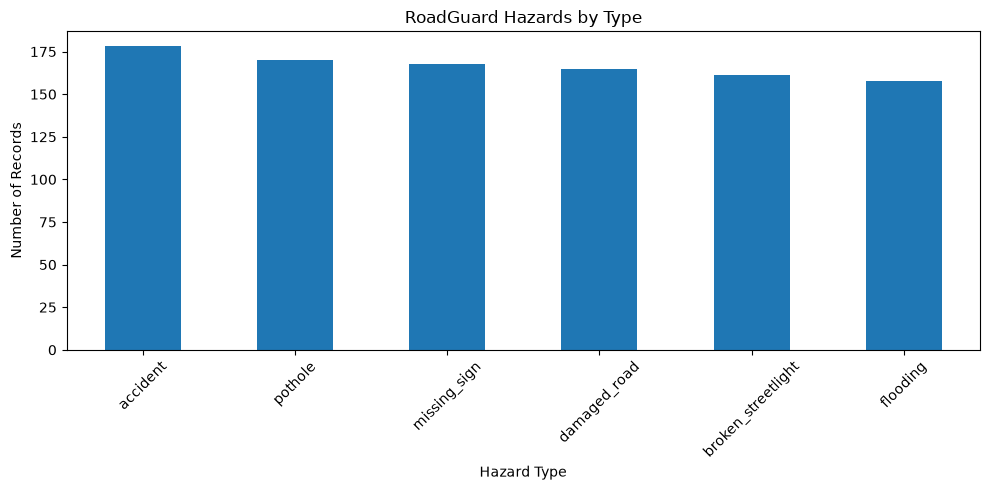

In [5]:
import matplotlib.pyplot as plt

hazard_counts = df["hazard_type"].value_counts()

plt.figure(figsize=(10, 5))

hazard_counts.plot(kind="bar")

plt.title("RoadGuard Hazards by Type")
plt.xlabel("Hazard Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [6]:
print("===== SEVERITY DISTRIBUTION =====")

print(df["severity"].value_counts().sort_index())


===== SEVERITY DISTRIBUTION =====
severity
1     116
2      90
3     117
4      90
5      95
6      93
7      99
8      97
9     103
10    100
Name: count, dtype: int64


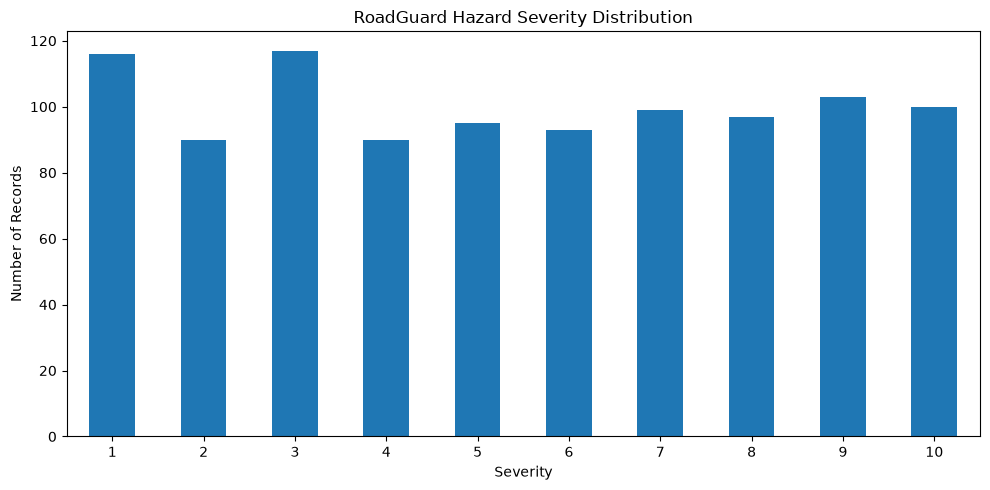

In [7]:
severity_counts = df["severity"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

severity_counts.plot(kind="bar")

plt.title("RoadGuard Hazard Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [8]:
high_risk = df[df["severity"] >= 8]

print("===== HIGH-RISK HAZARDS =====")
print("High-risk records:", len(high_risk))
print("Percentage:", round(len(high_risk) / len(df) * 100, 2), "%")

print("\nHigh-risk by hazard type:")
print(high_risk["hazard_type"].value_counts())

===== HIGH-RISK HAZARDS =====
High-risk records: 300
Percentage: 30.0 %

High-risk by hazard type:
hazard_type
flooding              59
missing_sign          55
damaged_road          51
accident              49
broken_streetlight    47
pothole               39
Name: count, dtype: int64


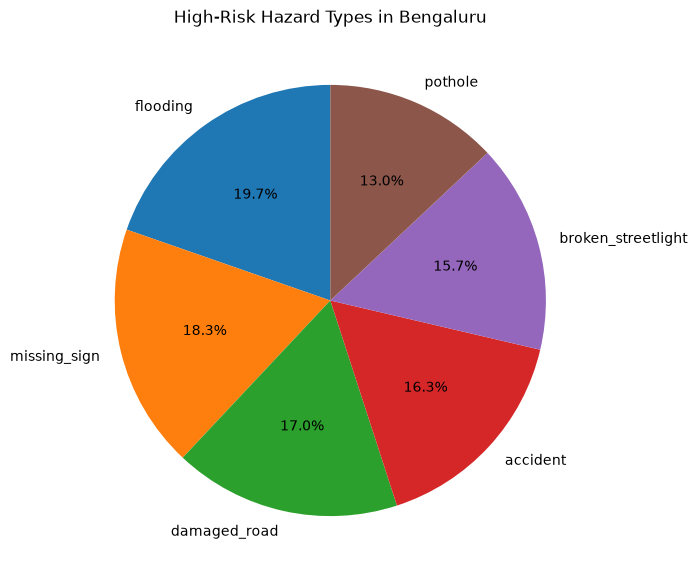

In [9]:
high_risk_counts = high_risk["hazard_type"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    high_risk_counts,
    labels=high_risk_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("High-Risk Hazard Types in Bengaluru")
plt.show()

In [10]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["month"] = df["timestamp"].dt.month

monthly_counts = df["month"].value_counts().sort_index()

print("===== MONTHLY HAZARD DISTRIBUTION =====")
print(monthly_counts)

===== MONTHLY HAZARD DISTRIBUTION =====
month
1    119
2    102
3    128
4    117
5    118
6    131
7    136
8    119
9     30
Name: count, dtype: int64


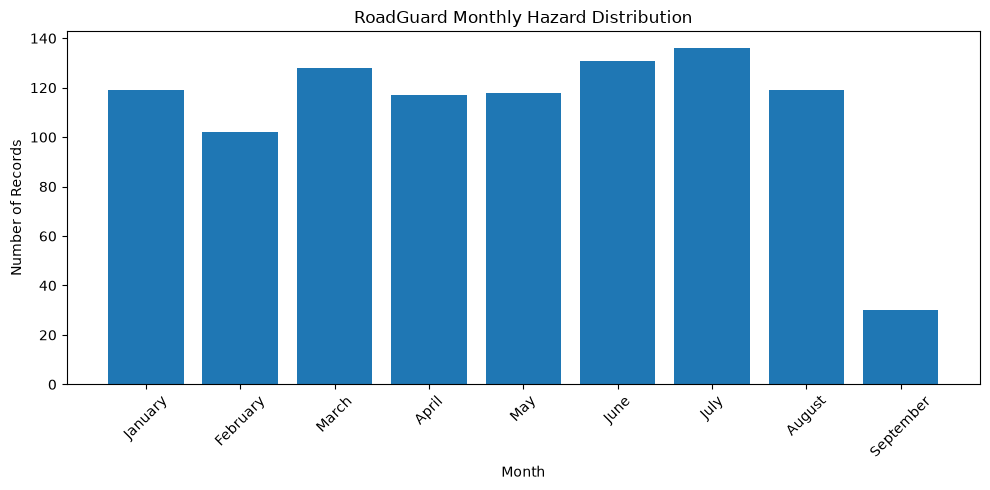

In [11]:
month_names = [
    "January", "February", "March", "April", "May",
    "June", "July", "August", "September"
]

monthly_counts = df["month"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.bar(
    [month_names[i - 1] for i in monthly_counts.index],
    monthly_counts.values
)

plt.title("RoadGuard Monthly Hazard Distribution")
plt.xlabel("Month")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
print("===== GEOGRAPHIC SUMMARY =====")

print("Latitude range:")
print(df["latitude"].min(), "to", df["latitude"].max())

print("\nLongitude range:")
print(df["longitude"].min(), "to", df["longitude"].max())

print("\nAverage location:")
print("Latitude:", round(df["latitude"].mean(), 6))
print("Longitude:", round(df["longitude"].mean(), 6))

===== GEOGRAPHIC SUMMARY =====
Latitude range:
12.850073 to 13.099781

Longitude range:
77.450021 to 77.749543

Average location:
Latitude: 12.974376
Longitude: 77.597193


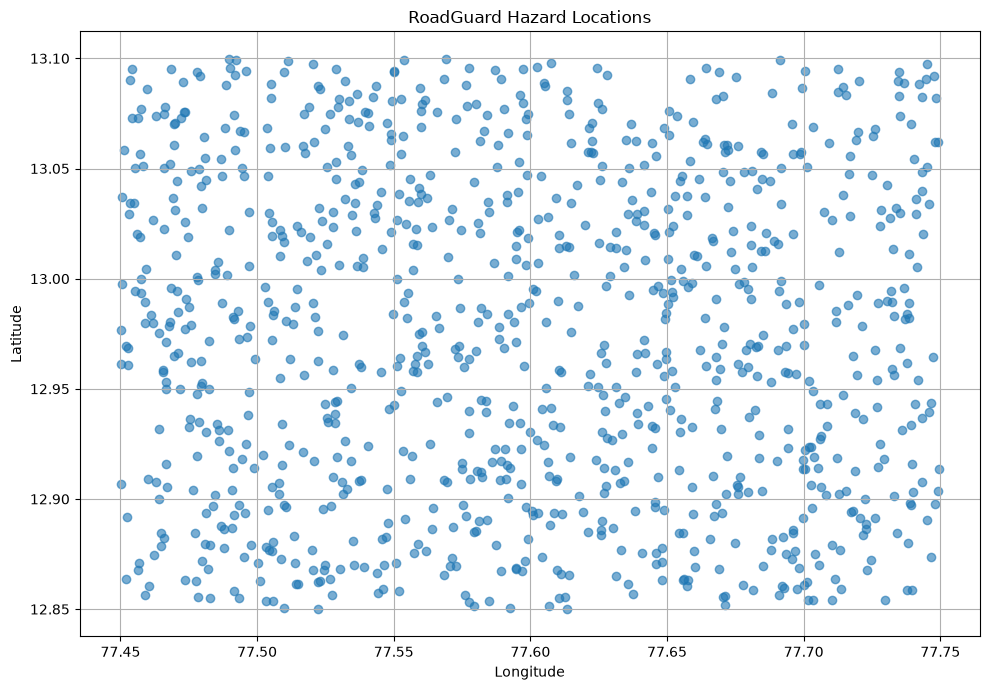

In [13]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df["longitude"],
    df["latitude"],
    alpha=0.6
)

plt.title("RoadGuard Hazard Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(True)
plt.tight_layout()
plt.show()

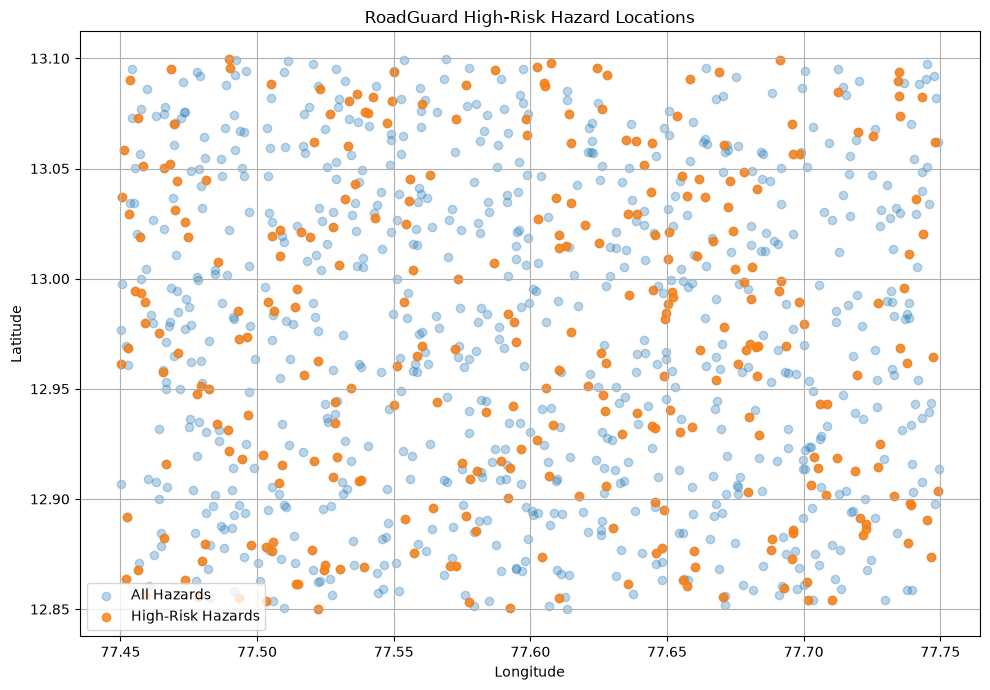

In [14]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df["longitude"],
    df["latitude"],
    alpha=0.3,
    label="All Hazards"
)

plt.scatter(
    high_risk["longitude"],
    high_risk["latitude"],
    alpha=0.8,
    label="High-Risk Hazards"
)

plt.title("RoadGuard High-Risk Hazard Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
print("===== AVERAGE SEVERITY BY HAZARD TYPE =====")

avg_severity = (
    df.groupby("hazard_type")["severity"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_severity.round(2))

===== AVERAGE SEVERITY BY HAZARD TYPE =====
hazard_type
flooding              5.96
broken_streetlight    5.56
missing_sign          5.51
damaged_road          5.30
accident              5.30
pothole               5.04
Name: severity, dtype: float64


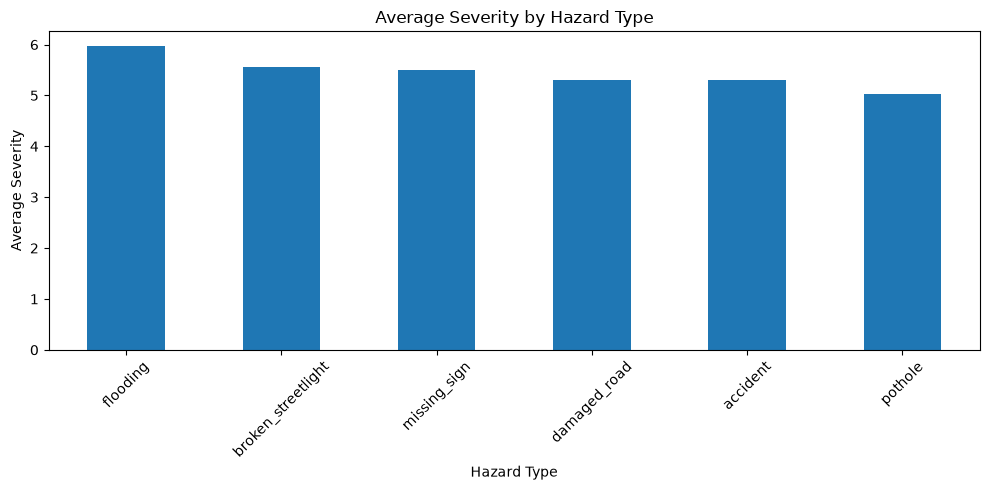

In [16]:
plt.figure(figsize=(10, 5))

avg_severity.plot(kind="bar")

plt.title("Average Severity by Hazard Type")
plt.xlabel("Hazard Type")
plt.ylabel("Average Severity")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [17]:
print("===== HIGH-RISK PERCENTAGE BY HAZARD TYPE =====")

high_risk_percentage = (
    df.groupby("hazard_type")["severity"]
    .apply(lambda x: (x >= 8).mean() * 100)
    .sort_values(ascending=False)
)

print(high_risk_percentage.round(2))

===== HIGH-RISK PERCENTAGE BY HAZARD TYPE =====
hazard_type
flooding              37.34
missing_sign          32.74
damaged_road          30.91
broken_streetlight    29.19
accident              27.53
pothole               22.94
Name: severity, dtype: float64
